# Comparación de Modelos Supervisados usando CV

Este proyecto tiene como objetivo comparar diferentes modelos de aprendizaje supervisado para predecir la tendencia del precio de Bitcoin utilizando validación cruzada.

## 1. Configuración y Carga de Datos

In [5]:
import pandas as pd
import numpy as np
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score

# Descargar el dataset
path = kagglehub.dataset_download("mczielinski/bitcoin-historical-data")
file_path = f"{path}/btcusd_1-min_data.csv"

# Cargar una muestra de los datos
df = pd.read_csv(file_path, nrows=100000)
df.head()

,Timestamp,Open,High,Low,Close,Volume
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0
3,1.325412e+09,4.58,4.58,4.58,4.58,0.0
4,1.325412e+09,4.58,4.58,4.58,4.58,0.0


## 2. Preparación de Datos y EDA

Creamos la variable objetivo y realizamos una inspección visual.

Columnas disponibles: ['Timestamp', 'Open', 'High', 'Low', 'Close', 'Volume', 'Target']


C:\Users\Zero\AppData\Local\Temp\ipykernel_3844\2829347983.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Target', data=df, palette='viridis')


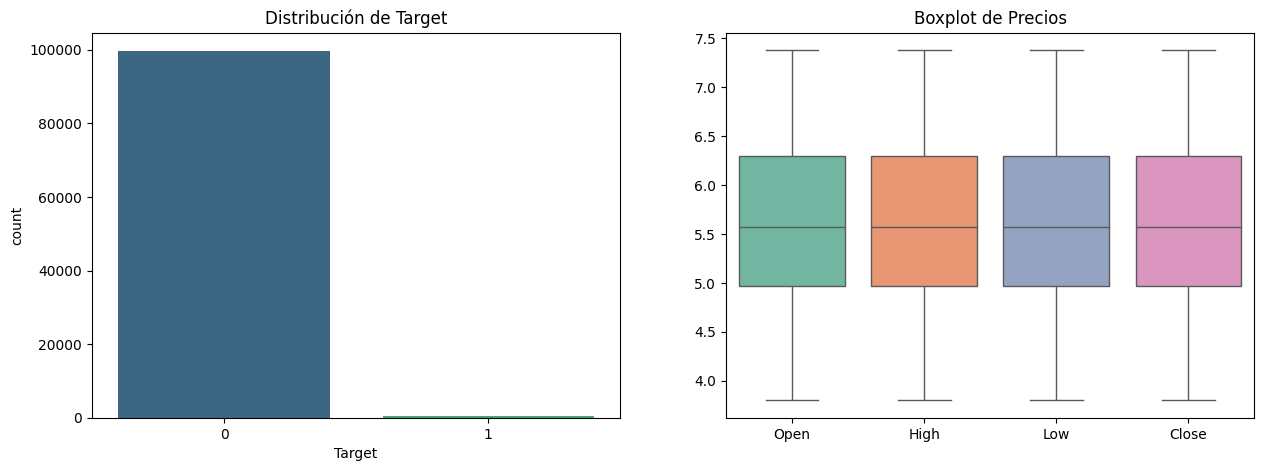

In [8]:
# 1. Limpieza y Creación de Target
df = df.dropna().copy()
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)
df = df.iloc[:-1]

print(f"Columnas disponibles: {df.columns.tolist()}")

# 2. Visualización Rápida
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.countplot(x='Target', data=df, palette='viridis')
plt.title('Distribución de Target')

plt.subplot(1, 2, 2)
sns.boxplot(data=df[['Open', 'High', 'Low', 'Close']], palette='Set2')
plt.title('Boxplot de Precios')
plt.show()

El gráfico de la izquierda muestra que la gran mayoría de los registros corresponden a la clase 0 (el precio no subió en el siguiente minuto). Esto es normal en datos financieros de alta frecuencia, y justifica por qué usamos ROC AUC y Validación Estratificada en lugar de simplemente el Accuracy.

El boxplot muestra que Open, High, Low y Close tienen distribuciones casi idénticas, lo cual es lógico para datos de 1 minuto. El escalado que aplicamos con StandardScaler ayudará a los modelos a manejar estos rangos de precios (de 4.0 a 7.5 en esta muestra) de forma eficiente.

## 3. División Estratificada (60/20/20)

In [9]:
X = df[['Open', 'High', 'Low', 'Close', 'Volume']]
y = df['Target']

# División 60/40
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)

# División 20/20
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Registros - Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Registros - Train: 59998, Val: 20000, Test: 20000


## 4. Pipeline y Entrenamiento con Validación Cruzada (K=5)

In [10]:
preprocessor = ColumnTransformer([('num', StandardScaler(), X.columns)])

models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier()
}

results_list = []
for name, model in models.items():
    pipeline = Pipeline([('pre', preprocessor), ('clf', model)])
    pipeline.fit(X_train, y_train)
    
    # Métricas base
    train_auc = roc_auc_score(y_train, pipeline.predict_proba(X_train)[:, 1])
    val_auc = roc_auc_score(y_val, pipeline.predict_proba(X_val)[:, 1])
    
    # CV
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc')
    
    results_list.append({
        'Modelo': name, 'Train AUC': train_auc, 'Val AUC': val_auc,
        'CV Mean': cv_scores.mean(), 'CV Std': cv_scores.std(), 'Folds': cv_scores
    })

df_results = pd.DataFrame(results_list)
display(df_results[['Modelo', 'Train AUC', 'Val AUC', 'CV Mean', 'CV Std']])

,Modelo,Train AUC,Val AUC,CV Mean,CV Std
0,Logistic Regression,0.587534,0.620183,0.586162,0.034877
1,Decision Tree,0.846418,0.519953,0.434237,0.035327
2,KNN,0.602860,0.526109,0.527285,0.010972


## 5. Visualización de Comparación de Modelos

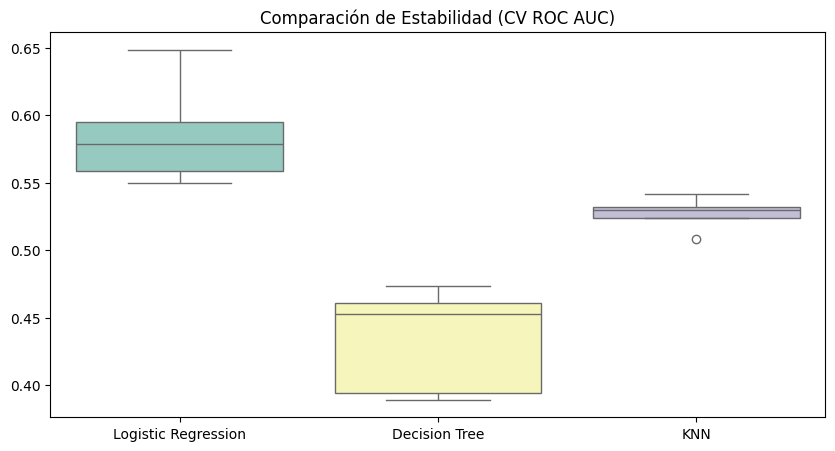

C:\Users\Zero\AppData\Local\Temp\ipykernel_3844\3478928632.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='CV Mean', data=df_results, palette='magma')


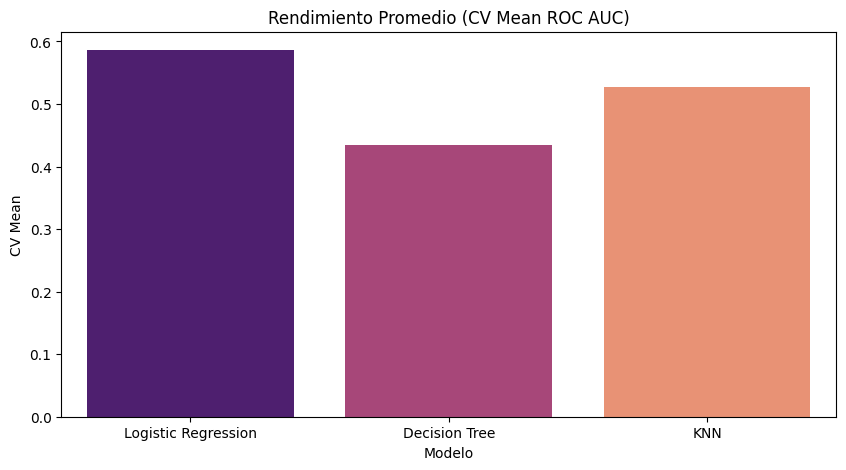

In [11]:
# Boxplot de estabilidad
cv_data = pd.DataFrame({row['Modelo']: row['Folds'] for _, row in df_results.iterrows()})
plt.figure(figsize=(10, 5))
sns.boxplot(data=cv_data, palette='Set3')
plt.title('Comparación de Estabilidad (CV ROC AUC)')
plt.show()

# Barplot de rendimiento promedio
plt.figure(figsize=(10, 5))
sns.barplot(x='Modelo', y='CV Mean', data=df_results, palette='magma')
plt.title('Rendimiento Promedio (CV Mean ROC AUC)')
plt.show()

### Logistic Regression (Ganador): 
No solo tiene la mediana más alta (cerca de 0.58), sino que su caja es relativamente compacta, lo que indica que su rendimiento es consistente a través de los diferentes folds de los datos.


**Decision Tree (Sobreajuste):** Su rendimiento es el más bajo (promedio por debajo de 0.45). Esto confirma que el árbol está "memorizando" el ruido de los datos de entrenamiento y falla estrepitosamente al intentar predecir datos nuevos (peor que el azar).

**KNN (Estable pero Inferior):** Aunque es muy estable (caja pequeña), su rendimiento está estancado alrededor de 0.53. Además, presenta un valor atípico (el punto debajo de la caja), lo que sugiere que en algún segmento de los datos su lógica de "vecinos cercanos" falló.

## 6. Conclusiones y Evaluación Final

In [12]:
best_name = df_results.loc[df_results['CV Mean'].idxmax()]['Modelo']
final_model = Pipeline([('pre', preprocessor), ('clf', models[best_name])])
final_model.fit(X_train, y_train)
test_auc = roc_auc_score(y_test, final_model.predict_proba(X_test)[:, 1])
print(f"Ganador: {best_name}")
print(f"ROC AUC Final en Test: {test_auc:.4f}")

Ganador: Logistic Regression
ROC AUC Final en Test: 0.5737


 El valor final de 0.5737 en el conjunto de prueba confirma la robustez de la Regresión Logística, ya que es muy cercano al promedio obtenido en la validación cruzada (0.58). Esto demuestra una excelente capacidad de generalización.